# Safe Highway Overtaking with Continuous MPC

## 1. Requirement

The ego vehicle should drive on a multi-lane highway, maintain safe longitudinal distance, and perform overtaking when necessary.

Unlike the previous discrete MPC implementation, the controller now directly optimizes continuous vehicle controls:

$$
u_t =
\begin{bmatrix}
a_t \\
\delta_t
\end{bmatrix},
$$

where:

- $a_t$ is longitudinal acceleration,
- $\delta_t$ is steering input.

The controller repeatedly solves a finite-horizon optimization problem:

$$
U_t^*=
\arg\min_U J(X,U)
$$

subject to:

$$
x_{k+1}=f(x_k,u_k),
$$

vehicle-control limits, road boundaries, and collision-avoidance constraints.

Only the first control input is applied:

$$
u_t=u_{0|t}^*.
$$

The optimization is repeated from the newly observed state at the next timestep.

## 2. Imports and Environment Setup

In [4]:
import gymnasium as gym
import highway_env

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [154]:
config = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 12,
        "features": [
            "presence",
            "x",
            "y",
            "vx",
            "vy"
        ],
        "absolute": False,
        "normalize": False,
        "see_behind": True
    },

    "action": {
        "type": "ContinuousAction"
    },

    "lanes_count": 4,
    "vehicles_count": 50,
    "vehicles_density": 2.0,

    "simulation_frequency": 15,
    "policy_frequency": 10,

    "duration": 40
}

env.close()

env = gym.make(
    "highway-v0",
    render_mode="rgb_array",
    config=config
)

obs, info = env.reset(seed=42)

In [90]:
def show_env(env, figsize=(12, 4)):
    frame = env.render()

    plt.figure(figsize=figsize)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

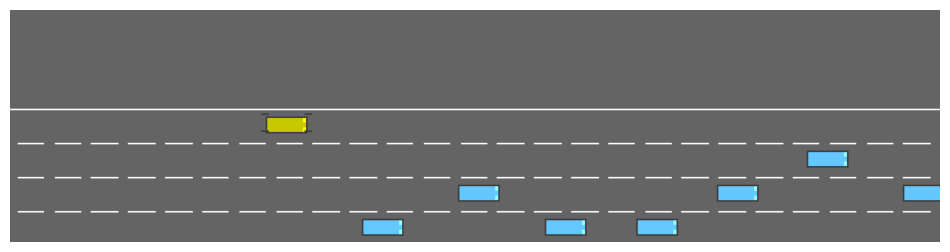

In [155]:
show_env(env)

## 3. State and Control Definition

The ego vehicle state is defined as:

$$
x =
\begin{bmatrix}
p_x \\
p_y \\
\psi \\
v
\end{bmatrix}
$$

where:

- $p_x$: longitudinal position,
- $p_y$: lateral position,
- $\psi$: heading angle,
- $v$: vehicle speed.

The continuous control input is:

$$
u =
\begin{bmatrix}
a \\
\delta
\end{bmatrix}
$$

where:

- $a$: longitudinal acceleration,
- $\delta$: steering angle.

## 4. Vehicle Dynamics

The continuous MPC uses a kinematic bicycle model for predicting the ego vehicle motion.

The state is:

$$
x=
\begin{bmatrix}
p_x \\
p_y \\
\psi \\
v
\end{bmatrix}
$$

and the control input is:

$$
u=
\begin{bmatrix}
a \\
\delta
\end{bmatrix}.
$$

The continuous-time dynamics are:

$$
\dot p_x=v\cos\psi
$$

$$
\dot p_y=v\sin\psi
$$

$$
\dot\psi=\frac{v}{L}\tan\delta
$$

$$
\dot v=a.
$$

Using a sampling interval $\Delta t$, the model is discretized as:

$$
x_{k+1}=f(x_k,u_k).
$$

In [2]:
DT = 0.1
WHEELBASE = 2.5

A_MIN = -5.0
A_MAX = 3.0

DELTA_MIN = -0.35
DELTA_MAX = 0.35

V_MIN = 0.0
V_MAX = 30.0

In [6]:
def dynamics(x, u, dt=DT):

    px, py, psi, v = x
    a, delta = u

    px_next = (
        px
        + dt * v * np.cos(psi)
    )

    py_next = (
        py
        + dt * v * np.sin(psi)
    )

    psi_next = (
        psi
        + dt * v / WHEELBASE * np.tan(delta)
    )

    v_next = (
        v
        + dt * a
    )

    return np.array([
        px_next,
        py_next,
        psi_next,
        v_next
    ])

## 5. Prediction Rollout

For an initial state $x_0$ and a candidate control sequence:

$$
U=
\{
u_0,
u_1,
\ldots,
u_{N-1}
\},
$$

the dynamics model predicts:

$$
x_{k+1}=f(x_k,u_k).
$$

This produces the predicted trajectory:

$$
X=
\{
x_0,
x_1,
\ldots,
x_N
\}.
$$

In [7]:
def rollout(x0, U):

    X = [x0]

    x = x0.copy()

    for u in U:

        x = dynamics(
            x,
            u
        )

        X.append(x)

    return np.array(X)

In [8]:
N = 20

In [9]:
x0 = np.array([
    0.0,    # px
    0.0,    # py
    0.0,    # heading
    20.0    # speed
])

U_test = np.zeros((N, 2))

X_test = rollout(
    x0,
    U_test
)

print("Initial state:", X_test[0])
print("Final state:", X_test[-1])

Initial state: [ 0.  0.  0. 20.]
Final state: [40.  0.  0. 20.]


## 6. Objective Function

The MPC objective encourages the ego vehicle to:

1. maintain the desired cruising speed,
2. move toward a desired lateral lane position,
3. avoid unnecessarily aggressive control inputs.

The running cost is:

$$
\ell(x_k,u_k)=
w_v(v_k-v_{\text{ref}})^2
+
w_y(p_{y,k}-y_{\text{ref}})^2
+
w_a a_k^2
+
w_\delta \delta_k^2.
$$

The total finite-horizon objective is:

$$
J=
\sum_{k=0}^{N-1}
\ell(x_k,u_k)
+
V_f(x_N).
$$

In [161]:
V_REF = 25.0

W_SPEED = 1.0
W_LATERAL = 2.0

W_ACCEL = 0.1
W_STEER = 0.5

W_TERMINAL = 5.0

W_LANE_CHANGE = 5.0

W_DACCEL = 0.1
W_DSTEER = 10.0

In [162]:
LANE_WIDTH = 4.0

def lane_center(lane_index):
    return lane_index * LANE_WIDTH

In [163]:
def objective(U_flat, x0, target_lane, current_lane):

    U = U_flat.reshape(N, 2)

    X = rollout(
        x0,
        U
    )

    y_ref = lane_center(target_lane)

    cost = 0.0

    for k in range(N):

        px, py, psi, v = X[k]
        a, delta = U[k]

        speed_cost = (
            W_SPEED
            * (v - V_REF)**2
        )

        lateral_cost = (
            W_LATERAL
            * (py - y_ref)**2
        )

        control_cost = (
            W_ACCEL * a**2
            +
            W_STEER * delta**2
        )

        cost += (
            speed_cost
            + lateral_cost
            + control_cost
        )
        
        # Control smoothness
        if k > 0:
    
            da = (
                U[k, 0]
                - U[k - 1, 0]
            )
    
            ddelta = (
                U[k, 1]
                - U[k - 1, 1]
            )
    
            cost += (
                W_DACCEL * da**2
                +
                W_DSTEER * ddelta**2
            )

    # Terminal state
    _, py_N, _, v_N = X[-1]

    terminal_cost = W_TERMINAL * (
        (v_N - V_REF)**2
        +
        (py_N - y_ref)**2
    )

    cost += terminal_cost

    # Discourage unnecessary lane changes
    if target_lane != current_lane:
        cost += W_LANE_CHANGE

    return cost

## 7. Constraints

The continuous MPC must satisfy:

### Control constraints

$$
a_{\min}\le a_k\le a_{\max}
$$

$$
\delta_{\min}\le\delta_k\le\delta_{\max}
$$

### Speed constraints

$$
v_{\min}\le v_k\le v_{\max}
$$

### Road-boundary constraints

The vehicle should remain inside the available road:

$$
y_{\min}\le p_{y,k}\le y_{\max}.
$$

### Collision-avoidance constraints

For nearby traffic vehicles, the ego trajectory should maintain sufficient longitudinal and lateral separation.

These safety requirements are treated as hard constraints rather than only as objective penalties.

In [164]:
control_bounds = []

for _ in range(N):

    control_bounds.append(
        (A_MIN, A_MAX)
    )

    control_bounds.append(
        (DELTA_MIN, DELTA_MAX)
    )

In [165]:
ROAD_Y_MIN = -2.0
ROAD_Y_MAX = 14.0

In [166]:
def state_constraints(U_flat, x0):

    U = U_flat.reshape(N, 2)

    X = rollout(
        x0,
        U
    )

    constraints = []

    for x in X[1:]:

        px, py, psi, v = x

        # Speed limits
        constraints.append(
            v - V_MIN
        )

        constraints.append(
            V_MAX - v
        )

        # Road boundaries
        constraints.append(
            py - ROAD_Y_MIN
        )

        constraints.append(
            ROAD_Y_MAX - py
        )

    return np.array(constraints)

In [167]:
state_constraint = {
    "type": "ineq",
    "fun": state_constraints
}

### Traffic Prediction

For the first implementation, surrounding vehicles are predicted using a constant-velocity model:

$$
p_x^i(k)=
p_x^i(0)
+
k\Delta t\,v_x^i
$$

and:

$$
p_y^i(k)=
p_y^i(0).
$$

This is a simplified short-horizon traffic model.

Collision avoidance is represented using an elliptical safety region around each traffic vehicle.

In [168]:
SAFE_LONGITUDINAL = 8.0
SAFE_LATERAL = 2.0

In [169]:
def traffic_constraints(
    U_flat,
    x0,
    traffic
):

    U = U_flat.reshape(N, 2)

    X = rollout(
        x0,
        U
    )

    constraints = []

    for k in range(1, N + 1):

        ego_x = X[k, 0]
        ego_y = X[k, 1]

        t = k * DT

        for vehicle in traffic:

            traffic_x = (
                vehicle["x"]
                + vehicle["vx"] * t
            )

            traffic_y = vehicle["y"]

            dx = ego_x - traffic_x
            dy = ego_y - traffic_y

            safety_value = (
                (dx / SAFE_LONGITUDINAL)**2
                +
                (dy / SAFE_LATERAL)**2
                - 1.0
            )

            constraints.append(
                safety_value
            )

    return np.array(constraints)

## 8. Highway-env State Extraction

The MPC model uses the ego state:

$$
x=
[p_x,p_y,\psi,v].
$$

Highway-env provides these quantities internally through the controlled vehicle object.

For surrounding traffic, we extract:

$$
[p_x^i,p_y^i,v_x^i]
$$

for each nearby vehicle.

These quantities are used by the constant-velocity traffic prediction model inside the collision-avoidance constraints.

In [170]:
def get_ego_state(env):

    ego = env.unwrapped.vehicle

    px = float(ego.position[0])
    py = float(ego.position[1])
    psi = float(ego.heading)
    v = float(ego.speed)

    return np.array([
        px,
        py,
        psi,
        v
    ])

In [171]:
def get_traffic_state(env):

    ego = env.unwrapped.vehicle

    traffic = []

    for vehicle in env.unwrapped.road.vehicles:

        if vehicle is ego:
            continue

        traffic.append({
            "x": float(vehicle.position[0]),
            "y": float(vehicle.position[1]),
            "vx": float(
                vehicle.speed
                * np.cos(vehicle.heading)
            )
        })

    return traffic

In [172]:
x0 = get_ego_state(env)
traffic = get_traffic_state(env)

print("Ego state:")
print(x0)

print("\nNumber of traffic vehicles:")
print(len(traffic))

print("\nFirst traffic vehicles:")
for vehicle in traffic[:5]:
    print(vehicle)

Ego state:
[3.20500631e+02 1.04418813e+01 2.06487733e-01 2.50301135e+01]

Number of traffic vehicles:
50

First traffic vehicles:
{'x': 289.02009386373715, 'y': 0.0, 'vx': 14.19033211525658}
{'x': 314.8965289900984, 'y': 12.0, 'vx': 14.953806997551156}
{'x': 303.0339472502643, 'y': 6.269867926236071, 'vx': 11.65992434593131}
{'x': 334.3988217109222, 'y': 8.0, 'vx': 18.11439552132564}
{'x': 321.1839139863371, 'y': 0.0, 'vx': 15.333096558977354}


## 9. Assemble the MPC Optimization

In [173]:
U0 = np.zeros((N, 2))
U0_flat = U0.flatten()

In [174]:
def make_constraints(x0, traffic):

    return [
        {
            "type": "ineq",
            "fun": state_constraints,
            "args": (x0,)
        },
        {
            "type": "ineq",
            "fun": traffic_constraints,
            "args": (x0, traffic)
        }
    ]

In [175]:
def solve_mpc(
    x0,
    traffic,
    target_lane,
    current_lane,
    U_initial=None
):

    if U_initial is None:
        U_initial = np.zeros((N, 2))

    constraints = make_constraints(
        x0,
        traffic
    )

    result = minimize(
        objective,
        U_initial.flatten(),
        args=(x0, target_lane, current_lane),
        method="SLSQP",
        bounds=control_bounds,
        constraints=constraints,
        options={
            "maxiter": 100,
            "ftol": 1e-3,
            "disp": False
        }
    )

    U_opt = result.x.reshape(N, 2)

    return result, U_opt

In [190]:
x0 = get_ego_state(env)
traffic = get_traffic_state(env)

current_lane = env.unwrapped.vehicle.lane_index[2]

result, U_opt = solve_mpc(
    x0,
    traffic,
    target_lane,
    current_lane
)

print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.fun)

print("\nFirst control:")
print(U_opt[0])

Success: True
Message: Optimization terminated successfully
Cost: 96.3048597461764

First control:
[0.2448828 0.35     ]


In [191]:
X_opt = rollout(
    x0,
    U_opt
)

print("Initial state:")
print(X_opt[0])

print("\nTerminal state:")
print(X_opt[-1])

Initial state:
[178.98440819   0.           0.          25.        ]

Terminal state:
[ 2.27932042e+02  3.99848698e+00 -3.15512675e-04  2.49990501e+01]


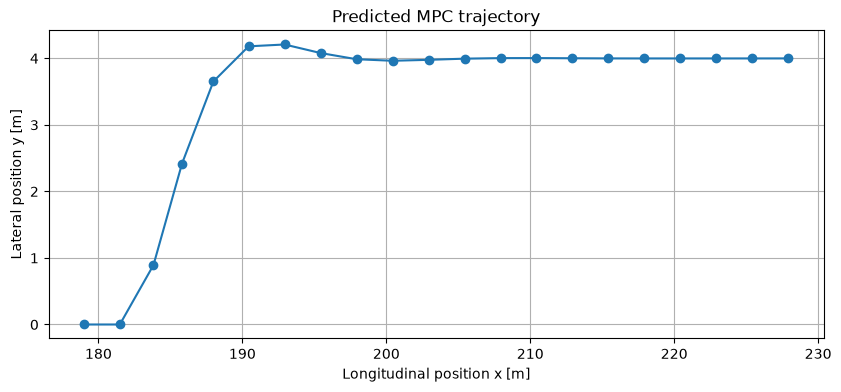

In [192]:
plt.figure(figsize=(10, 4))

plt.plot(
    X_opt[:, 0],
    X_opt[:, 1],
    marker="o"
)

plt.xlabel("Longitudinal position x [m]")
plt.ylabel("Lateral position y [m]")
plt.title("Predicted MPC trajectory")
plt.grid(True)

plt.show()

## 10. Commanded Lane-Change Test

Before running the full MPC controller online, we test whether the continuous optimizer can generate a smooth lane-change trajectory.

The ego vehicle starts in its current lane and is given an adjacent target lane.

For a lane change from lane $l$ to lane $l+1$:

$$
y_{\text{ref}}=
(l+1)w_{\text{lane}}.
$$

The optimizer must determine the continuous steering and acceleration sequence required to move toward the target lane while satisfying:

- control bounds,
- speed limits,
- road boundaries,
- traffic collision constraints.

In [193]:
x0 = get_ego_state(env)
traffic = get_traffic_state(env)

current_lane = int(
    env.unwrapped.vehicle.lane_index[2]
)

target_lane = min(
    current_lane + 1,
    config["lanes_count"] - 1
)

print("Current lane:", current_lane)
print("Target lane:", target_lane)

print(
    "Current y:",
    x0[1]
)

print(
    "Target y:",
    lane_center(target_lane)
)

Current lane: 0
Target lane: 1
Current y: 0.0
Target y: 4.0


In [195]:
result, U_opt = solve_mpc(
    x0,
    traffic,
    target_lane,
    current_lane
)

print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.fun)

print("\nFirst control:")
print(
    f"a     = {U_opt[0, 0]:.3f} m/s²"
)

print(
    f"delta = {U_opt[0, 1]:.3f} rad"
)

Success: True
Message: Optimization terminated successfully
Cost: 96.3048597461764

First control:
a     = 0.245 m/s²
delta = 0.350 rad


In [196]:
X_opt = rollout(
    x0,
    U_opt
)

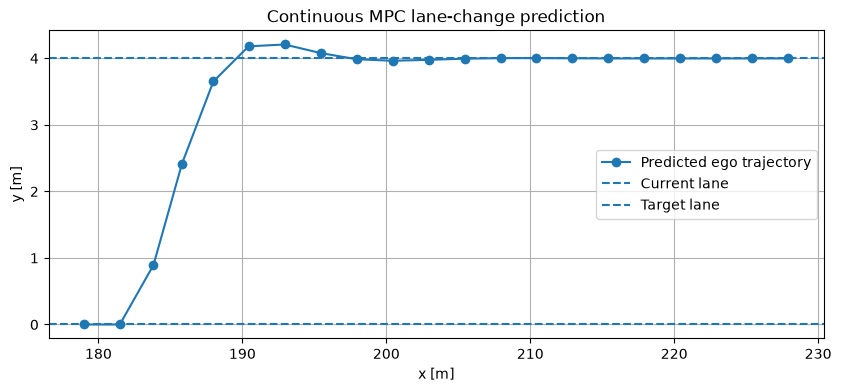

In [197]:
plt.figure(figsize=(10, 4))

plt.plot(
    X_opt[:, 0],
    X_opt[:, 1],
    marker="o",
    label="Predicted ego trajectory"
)

plt.axhline(
    lane_center(current_lane),
    linestyle="--",
    label="Current lane"
)

plt.axhline(
    lane_center(target_lane),
    linestyle="--",
    label="Target lane"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Continuous MPC lane-change prediction")
plt.grid(True)
plt.legend()

plt.show()

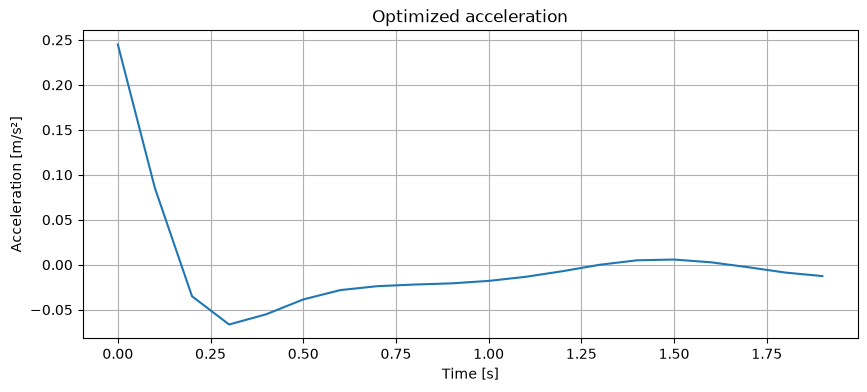

In [198]:
time = np.arange(N) * DT

plt.figure(figsize=(10, 4))

plt.plot(
    time,
    U_opt[:, 0]
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("Optimized acceleration")
plt.grid(True)

plt.show()

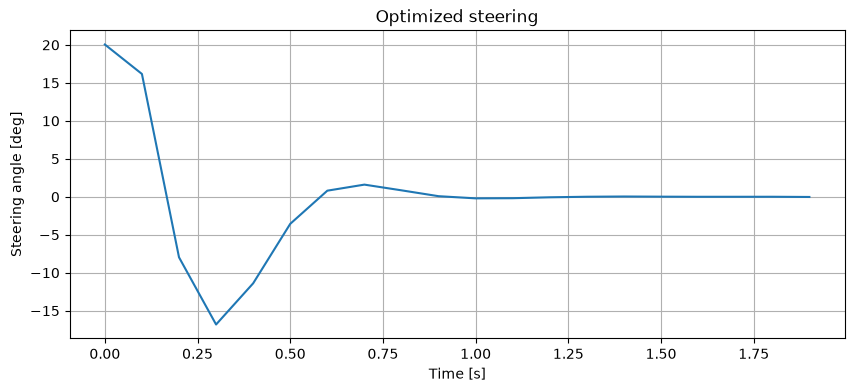

In [199]:
plt.figure(figsize=(10, 4))

plt.plot(
    time,
    np.rad2deg(U_opt[:, 1])
)

plt.xlabel("Time [s]")
plt.ylabel("Steering angle [deg]")
plt.title("Optimized steering")
plt.grid(True)

plt.show()

## 11. Receding-Horizon MPC

At each control step:

1. read the current ego and traffic state,
2. solve the finite-horizon optimization problem,
3. apply only the first optimized control input,
4. advance the simulator,
5. observe the new state,
6. repeat the optimization.

Thus:

$$
\boxed{
x_t
\rightarrow
U_t^*
\rightarrow
u_{0|t}^*
\rightarrow
x_{t+1}
\rightarrow
U_{t+1}^*
}
$$

In [200]:
def normalize_control(a, delta):

    if a >= 0:
        a_norm = a / A_MAX
    else:
        a_norm = -a / A_MIN

    delta_norm = delta / DELTA_MAX

    return np.array([
        np.clip(a_norm, -1.0, 1.0),
        np.clip(delta_norm, -1.0, 1.0)
    ])

In [201]:
def mpc_control_step(
    env,
    target_lane,
    U_warm=None
):

    x0 = get_ego_state(env)
    traffic = get_traffic_state(env)

    result, U_opt = solve_mpc(
        x0,
        traffic,
        target_lane,
        U_initial=U_warm
    )

    if not result.success:
        print("MPC warning:", result.message)

    # First optimized control
    a_cmd = U_opt[0, 0]
    delta_cmd = U_opt[0, 1]

    env_action = normalize_control(
        a_cmd,
        delta_cmd
    )

    return env_action, U_opt, result

In [202]:
def shift_controls(U):

    U_shift = np.zeros_like(U)

    U_shift[:-1] = U[1:]
    U_shift[-1] = U[-1]

    return U_shift

In [203]:
obs, info = env.reset(seed=42)

current_lane = int(
    env.unwrapped.vehicle.lane_index[2]
)

target_lane = min(
    current_lane + 1,
    config["lanes_count"] - 1
)

U_warm = None

history = []
frames = []

for t in range(50):

    frame = env.render()
    frames.append(frame)

    env_action, U_opt, result = mpc_control_step(
        env,
        target_lane,
        U_warm
    )

    x_before = get_ego_state(env)

    obs, reward, terminated, truncated, info = env.step(
        env_action
    )

    x_after = get_ego_state(env)

    history.append({
        "step": t,
        "x": x_after[0],
        "y": x_after[1],
        "heading": x_after[2],
        "speed": x_after[3],
        "a_cmd": U_opt[0, 0],
        "delta_cmd": U_opt[0, 1],
        "success": result.success,
        "cost": result.fun,
        "crashed": info["crashed"]
    })

    U_warm = shift_controls(
        U_opt
    )

    if terminated or truncated:
        break

TypeError: solve_mpc() missing 1 required positional argument: 'current_lane'

In [44]:
for row in history:
    print(
        f"step={row['step']:2d} | "
        f"y={row['y']:6.2f} | "
        f"v={row['speed']:5.2f} | "
        f"a={row['a_cmd']:6.2f} | "
        f"delta={np.rad2deg(row['delta_cmd']):6.2f} deg | "
        f"cost={row['cost']:8.2f} | "
        f"success={row['success']} | "
        f"crashed={row['crashed']}"
    )

step= 0 | y=  0.75 | v=25.05 | a=  0.45 | delta= 20.05 deg | cost=   87.79 | success=True | crashed=False
step= 1 | y=  1.90 | v=25.04 | a= -0.08 | delta= 20.05 deg | cost=   35.95 | success=True | crashed=False
step= 2 | y=  2.24 | v=25.04 | a= -0.13 | delta=-17.69 deg | cost=    9.89 | success=True | crashed=False
step= 3 | y=  2.81 | v=25.03 | a= -0.08 | delta=  0.46 deg | cost=    8.01 | success=True | crashed=False
step= 4 | y=  2.96 | v=25.03 | a= -0.07 | delta=-12.36 deg | cost=    3.12 | success=True | crashed=False
step= 5 | y=  3.33 | v=25.02 | a= -0.07 | delta=  2.32 deg | cost=    2.93 | success=True | crashed=False
step= 6 | y=  3.40 | v=25.02 | a= -0.07 | delta= -8.02 deg | cost=    0.97 | success=True | crashed=False
step= 7 | y=  3.61 | v=25.01 | a= -0.04 | delta=  1.25 deg | cost=    0.96 | success=True | crashed=False
step= 8 | y=  3.64 | v=25.01 | a= -0.03 | delta= -5.20 deg | cost=    0.33 | success=True | crashed=False
step= 9 | y=  3.79 | v=25.01 | a= -0.03 | delt

## 12. MPC-Based Lane Selection

Instead of specifying the target lane manually, the controller evaluates
the feasible lane choices around the ego vehicle.

For each candidate lane $l$:

$$
U_l^*=
\arg\min_U J(U,l)
$$

subject to the vehicle dynamics and safety constraints.

The controller then selects:

$$
l^*=
\arg\min_l J_l^*.
$$

Therefore, the MPC determines both:

- which lane is preferable,
- the continuous acceleration and steering trajectory required to reach it.

The discrete lane choice is evaluated externally, while the continuous
trajectory for each candidate lane is optimized by MPC.

In [45]:
def get_candidate_lanes(env):

    current_lane = int(
        env.unwrapped.vehicle.lane_index[2]
    )

    lanes_count = config["lanes_count"]

    candidates = [current_lane]

    if current_lane > 0:
        candidates.append(
            current_lane - 1
        )

    if current_lane < lanes_count - 1:
        candidates.append(
            current_lane + 1
        )

    return candidates

In [54]:
def select_lane_and_control(
    env,
    U_warm=None
):

    x0 = get_ego_state(env)
    traffic = get_traffic_state(env)

    current_lane = int(
        env.unwrapped.vehicle.lane_index[2]
    )

    candidate_lanes = get_candidate_lanes(
        env
    )

    solutions = []

    for target_lane in candidate_lanes:

        result, U_opt = solve_mpc(
            x0=x0,
            traffic=traffic,
            target_lane=target_lane,
            current_lane=current_lane,
            U_initial=U_warm
        )

        if result.success:

            solutions.append({
                "lane": target_lane,
                "cost": result.fun,
                "U": U_opt,
                "result": result
            })

    if len(solutions) == 0:
        return None

    best = min(
        solutions,
        key=lambda s: s["cost"]
    )

    return best

In [55]:
best = select_lane_and_control(
    env
)

if best is not None:

    print(
        "Selected lane:",
        best["lane"]
    )

    print(
        "Cost:",
        best["cost"]
    )

    print(
        "First control:",
        best["U"][0]
    )

Selected lane: 1
Cost: 6.1432005630454e-05
First control: [-1.09160489e-06 -1.58771178e-05]


In [57]:
def inspect_lane_candidates(env):

    x0 = get_ego_state(env)
    traffic = get_traffic_state(env)

    current_lane = int(
        env.unwrapped.vehicle.lane_index[2]
    )

    for target_lane in get_candidate_lanes(env):

        result, U_opt = solve_mpc(
            x0=x0,
            traffic=traffic,
            target_lane=target_lane,
            current_lane=current_lane
        )

        print(
            f"lane={target_lane} | "
            f"success={result.success} | "
            f"cost={result.fun:.2f} | "
            f"a0={U_opt[0,0]:.2f} | "
            f"delta0={U_opt[0,1]:.3f}"
        )

In [58]:
inspect_lane_candidates(env)

lane=1 | success=True | cost=0.00 | a0=-0.00 | delta0=-0.000
lane=0 | success=True | cost=92.79 | a0=0.43 | delta0=-0.350
lane=2 | success=True | cost=92.79 | a0=0.39 | delta0=0.350


## 13. Receding-Horizon MPC with Lane Selection

At every control step, the controller:

1. observes the current ego and traffic state,
2. identifies the feasible candidate lanes,
3. solves one continuous MPC problem for each candidate lane,
4. compares the optimized costs,
5. selects the minimum-cost lane and control trajectory,
6. applies only the first control input,
7. repeats the process from the new state.

Thus, both the lane decision and the continuous vehicle control are updated online.

In [59]:
def evaluate_lane_candidates(env, U_warm=None):

    x0 = get_ego_state(env)
    traffic = get_traffic_state(env)

    current_lane = int(
        env.unwrapped.vehicle.lane_index[2]
    )

    solutions = []

    for target_lane in get_candidate_lanes(env):

        result, U_opt = solve_mpc(
            x0=x0,
            traffic=traffic,
            target_lane=target_lane,
            current_lane=current_lane,
            U_initial=U_warm
        )

        solutions.append({
            "lane": target_lane,
            "cost": result.fun,
            "success": result.success,
            "U": U_opt,
            "result": result
        })

    return solutions

In [60]:
def choose_best_solution(solutions):

    feasible = [
        s for s in solutions
        if s["success"] and np.isfinite(s["cost"])
    ]

    if len(feasible) == 0:
        return None

    return min(
        feasible,
        key=lambda s: s["cost"]
    )

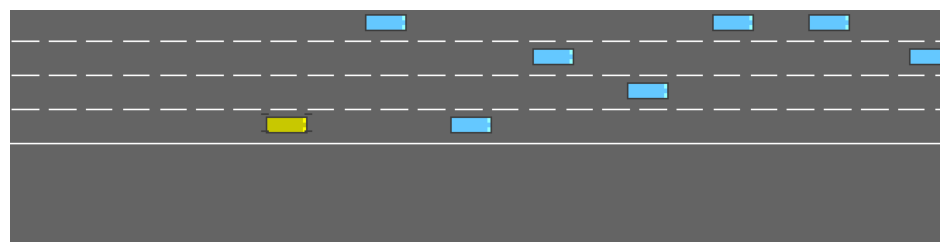

In [204]:
obs, info = env.reset()

show_env(env)

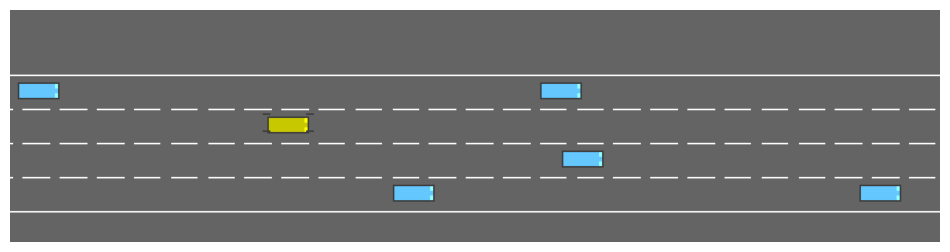

In [128]:
show_env(env)

In [205]:
U_warm = None

history = []
frames = []

for t in range(200):

    frames.append(env.render())

    solutions = evaluate_lane_candidates(
        env,
        U_warm
    )

    best = choose_best_solution(
        solutions
    )

    if best is None:
        print(
            f"Step {t}: no feasible MPC solution."
        )
        break

    selected_lane = best["lane"]
    U_opt = best["U"]

    # First optimized physical control
    a_cmd = U_opt[0, 0]
    delta_cmd = U_opt[0, 1]

    env_action = normalize_control(
        a_cmd,
        delta_cmd
    )

    # Candidate costs for logging
    lane_costs = {
        s["lane"]: (
            s["cost"]
            if s["success"]
            else np.inf
        )
        for s in solutions
    }

    obs, reward, terminated, truncated, info = (
        env.step(env_action)
    )

    ego = env.unwrapped.vehicle

    history.append({
        "step": t,
        "lane": int(ego.lane_index[2]),
        "selected_lane": selected_lane,
        "speed": float(ego.speed),
        "y": float(ego.position[1]),
        "a": float(a_cmd),
        "delta": float(delta_cmd),
        "costs": lane_costs,
        "best_cost": float(best["cost"]),
        "crashed": info["crashed"]
    })

    U_warm = shift_controls(
        U_opt
    )

    if terminated or truncated:
        break

Step 100: no feasible MPC solution.


In [206]:
for row in history:

    cost_text = " | ".join(
        f"J{lane}={cost:.1f}"
        if np.isfinite(cost)
        else f"J{lane}=inf"
        for lane, cost in sorted(
            row["costs"].items()
        )
    )

    print(
        f"step={row['step']:3d} | "
        f"lane={row['lane']} | "
        f"target={row['selected_lane']} | "
        f"v={row['speed']:5.2f} | "
        f"a={row['a']:6.2f} | "
        f"delta={np.rad2deg(row['delta']):6.2f} deg | "
        f"{cost_text} | "
        f"crashed={row['crashed']}"
    )

step=  0 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  1 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  2 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  3 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  4 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  5 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  6 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  7 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  8 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00 deg | J2=96.3 | J3=0.0 | crashed=False
step=  9 | lane=3 | target=3 | v=25.00 | a=  0.00 | delta=  0.00

In [139]:
import imageio.v2 as imageio

In [207]:
video_path = "safe_overtaking_continous_mpc.mp4"

imageio.mimsave(
    video_path,
    frames,
    fps=5
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [208]:
from IPython.display import Video

Video(
    video_path,
    embed=True,
    width=800
)